# Germany's cross-border flows, border by border

Physical flows (`flow.*`) live under the alphabetically FIRST zone of each
border, and **positive means that zone exports**. So DE↔FR is
`series('flow.FR', 'DE_LU')` (positive = DE exports), while DE↔AT is
`series('flow.DE_LU', 'AT')` — which we negate to keep the German
perspective. Flows are country-level: Denmark is `DK`, not `DK1`/`DK2`.

*Data: ENTSO-E Transparency Platform; Fraunhofer Energy-Charts CC BY 4.0; GIE — via [obsyd.dev](https://obsyd.dev) (free, AGPL-3.0). Descriptive, not a forecast.*

In [1]:
# pip install obsyd matplotlib
import datetime as dt
import matplotlib.pyplot as plt
from obsyd import Obsyd

ob = Obsyd()
# Ranges end YESTERDAY (UTC) — today's late hours may not be published yet.
END = dt.date.today() - dt.timedelta(days=1)
START = END - dt.timedelta(days=30)
# Flows are COUNTRY-level (Energy-Charts): DK not DK1/DK2, SE not SE4.
# Keys sorting after DE_LU live under DE_LU; the rest under the counterparty.
OUTBOUND = ['DK', 'FR', 'NL', 'NO', 'PL', 'SE']
INBOUND = ['AT', 'BE', 'CH', 'CZ']

In [2]:
import pandas as pd
from obsyd import ObsydNoData
flows = {}
for cp in OUTBOUND:
    try:
        flows[cp] = ob.series(f'flow.{cp}', 'DE_LU', start=START, end=END)['value']
    except ObsydNoData:
        pass
for cp in INBOUND:
    try:
        flows[cp] = -ob.series('flow.DE_LU', cp, start=START, end=END)['value']
    except ObsydNoData:
        pass
wide = pd.DataFrame(flows).resample('1D').mean() / 1000  # GW, daily mean
sorted(wide.columns)

['AT', 'BE', 'CH', 'CZ', 'DK', 'FR', 'NL', 'NO', 'PL', 'SE']

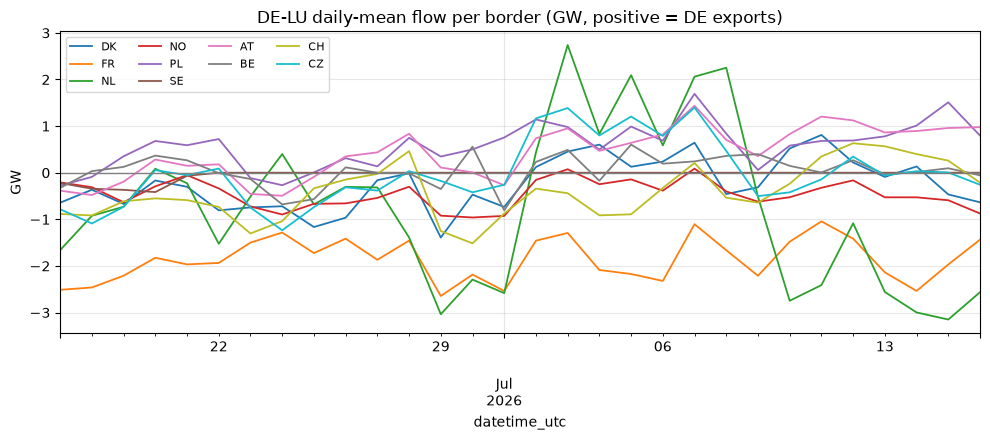

In [3]:
ax = wide.plot(figsize=(10, 4.5), lw=1.3)
ax.axhline(0, color='gray', lw=1)
ax.set_title('DE-LU daily-mean flow per border (GW, positive = DE exports)')
ax.set_ylabel('GW'); ax.legend(ncol=4, fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()

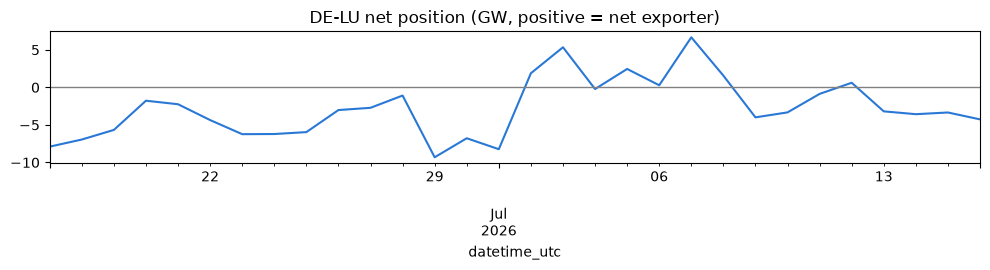

In [4]:
net = wide.sum(axis=1)
ax = net.plot(figsize=(10, 2.8), color='#2a78d6', lw=1.5)
ax.axhline(0, color='gray', lw=1)
ax.set_title('DE-LU net position (GW, positive = net exporter)')
plt.tight_layout()